# 501: Probability of No Further Warming - Scenario Group Analysis

This notebook calculates the probability that warming declines after net-zero emissions are achieved,
comparing three groups of scenarios:
1. **NZCO2**: Scenarios with "NZCO2" in the label
2. **NZKyoto**: Scenarios with "NZKyoto" in the label
3. **Base**: All other scenarios (no NZCO2 or NZKyoto in label)

**Criteria for decline:**
- Peak warming occurs before 2100
- Delta warming (peak - 2100) > 0°C

In [1]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import matplotlib.pyplot as plt

dotenv.load_dotenv()

True

In [2]:
# Configuration
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

# Guardrails for classifying decline
PEAK_YEAR_THRESHOLD = 2100  # Peak must occur before this year
DELTA_WARMING_THRESHOLD = 0.0  # Minimum decline in °C to count as decline

In [4]:
# Input metrics file - uses combined manifest from 401
MANIFEST_ID = "regenerated"
#METRICS_FILE = OUTPUT_FOLDER / f"500_gsat_metrics_{MANIFEST_ID}.csv"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_{MANIFEST_ID}.csv"

## Load and Filter Data

In [8]:
# Load metrics
metrics_df = pd.read_csv(METRICS_FILE)
print(f"Total rows: {len(metrics_df)}")
metrics_df.head()

Total rows: 1173000


,model,scenario,run_id,peak_year,year_netzero_co2,GSAT|ANTHROPOGENIC|peak,GSAT|ANTHROPOGENIC|netzero_co2,GSAT|ANTHROPOGENIC|2100,GSAT|NonCO2_GHG|peak_gsat,GSAT|NonCO2_GHG|2100,...,GSAT|CO2_NZCO2|peak_gsat,GSAT|CO2_NZCO2|2100,GSAT|CO2_NZCO2|delta_peak_gsat,GSAT|CO2_NZCO2|netzero_co2,GSAT|CO2_NZCO2|delta_netzero_co2,GSAT|CO2_Negative|peak_gsat,GSAT|CO2_Negative|2100,GSAT|CO2_Negative|delta_peak_gsat,GSAT|CO2_Negative|netzero_co2,GSAT|CO2_Negative|delta_netzero_co2
0,AIM/CGE 2.0,SSP1-19,0,2050,2056,1.656111,1.634448,1.437896,0.061244,-0.066797,...,1.570865,1.534157,-0.036708,1.571618,-0.037461,0.000000,-0.082263,-0.082263,0.0,-0.082263
1,AIM/CGE 2.0,SSP1-19,1,2079,2056,2.578803,2.528323,2.562571,0.266446,0.229079,...,2.974811,3.063602,0.088791,2.820937,0.242665,-0.041879,-0.125407,-0.083527,0.0,-0.125407
2,AIM/CGE 2.0,SSP1-19,2,2049,2056,1.792385,1.769938,1.576141,0.069950,-0.073931,...,1.680896,1.675590,-0.005307,1.691584,-0.015995,0.000000,-0.087428,-0.087428,0.0,-0.087428
3,AIM/CGE 2.0,SSP1-19,3,2041,2056,1.401658,1.343172,1.100911,0.093232,-0.101614,...,1.249076,1.170375,-0.078701,1.243943,-0.073568,0.000000,-0.066165,-0.066165,0.0,-0.066165
4,AIM/CGE 2.0,SSP1-19,4,2049,2056,1.667239,1.636622,1.412878,0.135616,-0.027525,...,1.548179,1.488891,-0.059288,1.545202,-0.056311,0.000000,-0.079328,-0.079328,0.0,-0.079328


In [9]:
# Filter for GSAT at NZCO2 year
all_df = metrics_df[["model", "scenario", "run_id", "peak_year", "year_netzero_co2", "GSAT|ANTHROPOGENIC|netzero_co2"]].copy()
all_df

,model,scenario,run_id,peak_year,year_netzero_co2,GSAT|ANTHROPOGENIC|netzero_co2
0,AIM/CGE 2.0,SSP1-19,0,2050,2056,1.634448
1,AIM/CGE 2.0,SSP1-19,1,2079,2056,2.528323
2,AIM/CGE 2.0,SSP1-19,2,2049,2056,1.769938
3,AIM/CGE 2.0,SSP1-19,3,2041,2056,1.343172
4,AIM/CGE 2.0,SSP1-19,4,2049,2056,1.636622
...,...,...,...,...,...,...
1172995,WITCH 5.0,NAVIGATE Demand-1.5°C-tec_u_NZCO2,595,2055,2080,1.580360
1172996,WITCH 5.0,NAVIGATE Demand-1.5°C-tec_u_NZCO2,596,2100,2080,2.792949
1172997,WITCH 5.0,NAVIGATE Demand-1.5°C-tec_u_NZCO2,597,2100,2080,2.179534
1172998,WITCH 5.0,NAVIGATE Demand-1.5°C-tec_u_NZCO2,598,2057,2080,1.582588


In [10]:
all_df[all_df["peak_year"]<all_df["year_netzero_co2"]]

,model,scenario,run_id,peak_year,year_netzero_co2,GSAT|ANTHROPOGENIC|netzero_co2
0,AIM/CGE 2.0,SSP1-19,0,2050,2056,1.634448
2,AIM/CGE 2.0,SSP1-19,2,2049,2056,1.769938
3,AIM/CGE 2.0,SSP1-19,3,2041,2056,1.343172
4,AIM/CGE 2.0,SSP1-19,4,2049,2056,1.636622
5,AIM/CGE 2.0,SSP1-19,5,2035,2056,1.061002
...,...,...,...,...,...,...
1172989,WITCH 5.0,NAVIGATE Demand-1.5°C-tec_u_NZCO2,589,2060,2080,1.533484
1172991,WITCH 5.0,NAVIGATE Demand-1.5°C-tec_u_NZCO2,591,2055,2080,1.360871
1172992,WITCH 5.0,NAVIGATE Demand-1.5°C-tec_u_NZCO2,592,2055,2080,1.588795
1172995,WITCH 5.0,NAVIGATE Demand-1.5°C-tec_u_NZCO2,595,2055,2080,1.580360


In [11]:
# Load 500b component metrics
all_df = pd.read_csv(OUTPUT_FOLDER / f"500b_component_metrics_{MANIFEST_ID}.csv")

# Filter to rows where net-zero CO2 year extraction was possible
all_df = all_df[all_df["GSAT|ANTHROPOGENIC|netzero_co2"].notna()].copy()
print(f"Rows with valid NZCO2-year extraction: {len(all_df)}")

# Classify scenarios into groups
all_df["scenario_group"] = all_df["scenario"].apply(
    lambda x: "Stylised Variants (NZCO2-hold)" if "NZCO2" in x
    else ("Stylised Variants (NZGHG-hold)" if "NZKyoto" in x else "Scenarios (NZCO2)")
)
# Build set of (model, stripped_scenario) keys from NZKyoto
nzkyoto_combos = set(
    all_df[all_df["scenario_group"] == "Stylised Variants (NZGHG-hold)"]
    .assign(scenario_key=lambda d: d["scenario"].str.replace("_NZKyoto", "", regex=False))
    [["model", "scenario_key"]]
    .itertuples(index=False, name=None)
)

# Find Base rows whose (model, scenario) pair matches a stripped NZKyoto combo
base_df = all_df[all_df["scenario_group"] == "Scenarios (NZCO2)"]
mask = base_df.apply(
    lambda r: (r["model"], r["scenario"]) in nzkyoto_combos, axis=1
)
base_nzghg = base_df[mask].copy()
base_nzghg["scenario_group"] = "Scenarios (NZGHG)"

# Concatenate without overwriting all_df
all_df_extended = pd.concat([all_df, base_nzghg], ignore_index=True)

# Show group counts
group_counts = (
    all_df_extended
    .drop_duplicates(subset=["model", "scenario", "scenario_group"])
    .groupby("scenario_group")
    .agg(
        n_rows=("run_id", "count"),
        n_unique_model_scenarios=("scenario", "count")
    )
)

print("\nScenario group summary:")
group_counts

Rows with valid NZCO2-year extraction: 1173000

Scenario group summary:


,n_rows,n_unique_model_scenarios
scenario_group,,
Scenarios (NZCO2),784,784
Scenarios (NZGHG),387,387
Stylised Variants (NZCO2-hold),784,784
Stylised Variants (NZGHG-hold),387,387


In [12]:
nzvals = pd.read_csv("/Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_revision/101_netzero_timings.csv")
nzvals[nzvals["achieve_netzero_co2"]==True]

,model,scenario,year_netzero_co2,year_netzero_kyoto_ar6gwp100,achieve_netzero_co2,achieve_netzero_ghg
0,AIM/CGE 2.0,SSP1-19,2056.0,2069.0,True,True
5,AIM/CGE 2.0,SSP2-19,2052.0,2061.0,True,True
6,AIM/CGE 2.0,SSP2-26,2074.0,NaN,True,False
11,AIM/CGE 2.0,SSP3-34,2089.0,NaN,True,False
15,AIM/CGE 2.0,SSP4-26,2084.0,NaN,True,False
...,...,...,...,...,...,...
1535,WITCH-GLOBIOM 4.4,CD-LINKS-INDC2030i_1600,2088.0,NaN,True,False
1537,WITCH-GLOBIOM 4.4,CD-LINKS-NDC2030i_1000,2066.0,2079.0,True,True
1539,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,2076.0,2087.0,True,True
1540,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,2095.0,NaN,True,False


In [13]:
all_df = pd.read_csv(OUTPUT_FOLDER / f"500b_component_metrics_{MANIFEST_ID}.csv")
len(all_df[['model', 'scenario']].copy().drop_duplicates())

1955

In [14]:
len(nzvals[['model', 'scenario']].copy().drop_duplicates())

1543

In [15]:
len(nzvals[nzvals["achieve_netzero_ghg"]==True])

388

In [16]:
len(all_df[['model', 'scenario']].copy().drop_duplicates())

1955

## Classify Ensemble Members

In [17]:
all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] = all_df_extended["GSAT|ANTHROPOGENIC|2100"] - all_df_extended["GSAT|ANTHROPOGENIC|netzero_co2"]
all_df_extended["GSAT|ANTHROPOGENIC|delta_peak_gsat"] = all_df_extended["GSAT|ANTHROPOGENIC|2100"] - all_df_extended["GSAT|ANTHROPOGENIC|peak"]

In [18]:
# Apply guardrails to classify each ensemble member as "decline" or not
all_df_extended["is_decline"] = (
    (all_df_extended["peak_year"] < PEAK_YEAR_THRESHOLD) &
    (all_df_extended["GSAT|ANTHROPOGENIC|delta_netzero_co2"] < DELTA_WARMING_THRESHOLD)
)

# Summary by group
decline_summary = all_df_extended.groupby("scenario_group").agg(
    total_members=("is_decline", "count"),
    decline_members=("is_decline", "sum"),
)
decline_summary["no_decline_members"] = decline_summary["total_members"] - decline_summary["decline_members"]
decline_summary["pct_decline"] = (decline_summary["decline_members"] / decline_summary["total_members"] * 100).round(1)
print("Decline classification by scenario group 2100 - NZCO2 year:")
decline_summary

Decline classification by scenario group 2100 - NZCO2 year:


,total_members,decline_members,no_decline_members,pct_decline
scenario_group,,,,
Scenarios (NZCO2),470400,388118,82282,82.5
Scenarios (NZGHG),232200,216190,16010,93.1
Stylised Variants (NZCO2-hold),470400,332447,137953,70.7
Stylised Variants (NZGHG-hold),232200,208938,23262,90.0


In [19]:
# Apply guardrails to classify each ensemble member as "decline" or not
all_df_extended_gsat = all_df_extended.copy()

all_df_extended_gsat["is_decline"] = (
    (all_df_extended_gsat["peak_year"] < PEAK_YEAR_THRESHOLD) &
    (all_df_extended_gsat["GSAT|ANTHROPOGENIC|delta_peak_gsat"] < DELTA_WARMING_THRESHOLD)
)

# Summary by group
decline_summary_gsat = all_df_extended_gsat.groupby("scenario_group").agg(
    total_members=("is_decline", "count"),
    decline_members=("is_decline", "sum"),
)
decline_summary_gsat["no_decline_members"] = decline_summary_gsat["total_members"] - decline_summary_gsat["decline_members"]
decline_summary_gsat["pct_decline"] = (decline_summary_gsat["decline_members"] / decline_summary_gsat["total_members"] * 100).round(1)
print("Decline classification by scenario group 2100 - peak GSAT year:")
decline_summary_gsat

Decline classification by scenario group 2100 - peak GSAT year:


,total_members,decline_members,no_decline_members,pct_decline
scenario_group,,,,
Scenarios (NZCO2),470400,416145,54255,88.5
Scenarios (NZGHG),232200,228087,4113,98.2
Stylised Variants (NZCO2-hold),470400,358430,111970,76.2
Stylised Variants (NZGHG-hold),232200,220729,11471,95.1


## Calculate Probability Per Scenario from NZCO2 year

In [20]:
# Group by model, scenario, and scenario_group, calculate probability
decline_prob = all_df_extended.groupby(["scenario_group", "model", "scenario"]).agg(
    n_ensemble=pd.NamedAgg(column="run_id", aggfunc="count"),
    n_decline=pd.NamedAgg(column="is_decline", aggfunc="sum"),
).reset_index()

# Calculate probability
decline_prob["prob_decline"] = decline_prob["n_decline"] / decline_prob["n_ensemble"]
decline_prob["prob_decline_pct"] = (decline_prob["prob_decline"] * 100).round(1)

print(f"Calculated probabilities for {len(decline_prob)} scenarios")
decline_prob.head(10)

Calculated probabilities for 2342 scenarios


,scenario_group,model,scenario,n_ensemble,n_decline,prob_decline,prob_decline_pct
0,Scenarios (NZCO2),AIM/CGE 2.0,SSP1-19,600,589,0.981667,98.2
1,Scenarios (NZCO2),AIM/CGE 2.0,SSP2-19,600,598,0.996667,99.7
2,Scenarios (NZCO2),AIM/CGE 2.0,SSP2-26,600,494,0.823333,82.3
3,Scenarios (NZCO2),AIM/CGE 2.0,SSP3-34,600,150,0.250000,25.0
4,Scenarios (NZCO2),AIM/CGE 2.0,SSP4-26,600,527,0.878333,87.8
5,Scenarios (NZCO2),AIM/CGE 2.0,SSP5-26,600,446,0.743333,74.3
6,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NDC2030i_1000,600,494,0.823333,82.3
7,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NPi2020_1000,600,180,0.300000,30.0
8,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NPi2020_400,600,598,0.996667,99.7
9,Scenarios (NZCO2),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Cost-Effective,600,481,0.801667,80.2


In [21]:
# Create structured summary table for each group
def create_group_summary(df, group_name):
    """Create summary statistics for a scenario group."""
    group_data = df[df["scenario_group"] == group_name]
    
    summary = {
        "Group": group_name,
        "N Scenarios": len(group_data),
        "Median (%)": group_data["prob_decline_pct"].median().round(1),
        "5th Pctl (%)": group_data["prob_decline_pct"].quantile(0.05).round(1),
        "17th Pctl (%)": group_data["prob_decline_pct"].quantile(0.17).round(1),
        "10th Pctl (%)": group_data["prob_decline_pct"].quantile(0.1).round(1),
        "34th Pctl (%)": group_data["prob_decline_pct"].quantile(0.34).round(1),
        "67th Pctl (%)": group_data["prob_decline_pct"].quantile(0.67).round(1),
        "83rd Pctl (%)": group_data["prob_decline_pct"].quantile(0.83).round(1),
        "90th Pctl (%)": group_data["prob_decline_pct"].quantile(0.9).round(1),
        "95th Pctl (%)": group_data["prob_decline_pct"].quantile(0.95).round(1),
    }
    return summary

# Create summary for each group
summaries = []
for group in ["Scenarios (NZCO2)", "Scenarios (NZGHG)", "Stylised Variants (NZCO2-hold)", "Stylised Variants (NZGHG-hold)"]:
    summaries.append(create_group_summary(decline_prob, group))

summary_table = pd.DataFrame(summaries)
print("Summary Table: Probability of Peak-and-Decline behavior by Scenario Group")
summary_table

Summary Table: Probability of Peak-and-Decline behavior by Scenario Group


,Group,N Scenarios,Median (%),5th Pctl (%),17th Pctl (%),10th Pctl (%),34th Pctl (%),67th Pctl (%),83rd Pctl (%),90th Pctl (%),95th Pctl (%)
0,Scenarios (NZCO2),784,89.8,39.7,65.8,57.3,81.5,94.7,98.2,99.2,99.8
1,Scenarios (NZGHG),387,95.5,77.2,86.9,82.5,93.7,97.8,99.2,99.8,100.0
2,Stylised Variants (NZCO2-hold),784,76.3,29.0,52.0,42.8,66.7,82.3,87.8,91.9,96.2
3,Stylised Variants (NZGHG-hold),387,92.2,73.7,81.7,77.7,89.0,95.3,98.0,99.2,99.7


In [22]:
rename_map = {
    "Scenarios (NZCO2)":         "Scenarios\n(NZCO2)",
    "Scenarios (NZGHG)":         "Scenarios\n(NZGHG)",
    "Stylised Variants (NZCO2-hold)": "Stylised Variants\n(NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)": "Stylised Variants\n(NZGHG-hold)",
}

summary_table["Group"] = summary_table["Group"].replace(rename_map)

In [23]:
summary_table

,Group,N Scenarios,Median (%),5th Pctl (%),17th Pctl (%),10th Pctl (%),34th Pctl (%),67th Pctl (%),83rd Pctl (%),90th Pctl (%),95th Pctl (%)
0,Scenarios\n(NZCO2),784,89.8,39.7,65.8,57.3,81.5,94.7,98.2,99.2,99.8
1,Scenarios\n(NZGHG),387,95.5,77.2,86.9,82.5,93.7,97.8,99.2,99.8,100.0
2,Stylised Variants\n(NZCO2-hold),784,76.3,29.0,52.0,42.8,66.7,82.3,87.8,91.9,96.2
3,Stylised Variants\n(NZGHG-hold),387,92.2,73.7,81.7,77.7,89.0,95.3,98.0,99.2,99.7


In [24]:
fig, ax = plt.subplots(figsize=(11, len(summary_table) * 0.2))
ax.axis("off")

table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
  #  rowLabels=summary_table.index,
    loc="center",
    cellLoc="center",  # centers cell contents
    colLoc="center",   # centers column headers
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.3,1.9)

header_height = 0.3  # adjust to taste
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")
    
# Bold column headers (row index 0)
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")  # light grey background

fig.savefig(PLOT_FOLDER / "501_nfw_nzco2_table.png", bbox_inches="tight", dpi=300)
plt.close(fig)

In [25]:
groups = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]

def format_decline_summary(df, group_name):
    group_data = df[df["scenario_group"] == group_name]["prob_decline_pct"]
    return [
        f"{group_data.median():.1f}%",
        f"({group_data.quantile(0.17):.1f}% to {group_data.quantile(0.83):.1f}%)",
        f"({group_data.quantile(0.05):.1f}% to {group_data.quantile(0.95):.1f}%)",
    ]

stat_labels = [
    "Median [%]",
    "(p34 to p67) [%]",
    "(p17 to p83) [%]",
    "(p10 to p90) [%]",
    "(p05 to p95) [%]",
    "N scenarios",

]

def format_decline_summary(df, group_name):
    group_data = df[df["scenario_group"] == group_name]["prob_decline_pct"]
    return [
        f"{group_data.median():.1f}%",
        f"({group_data.quantile(0.34):.1f}% to {group_data.quantile(0.67):.1f}%)",
        f"({group_data.quantile(0.17):.1f}% to {group_data.quantile(0.83):.1f}%)",
        f"({group_data.quantile(0.10):.1f}% to {group_data.quantile(0.90):.1f}%)",
        f"({group_data.quantile(0.05):.1f}% to {group_data.quantile(0.95):.1f}%)",
        f"{len(group_data)}",
    ]

rows = []
for stat_label, val_idx in zip(stat_labels, [0, 1, 2, 3, 4, 5]):
    row = {"Statistic": stat_label}
    for grp in groups:
        vals = format_decline_summary(decline_prob, grp)
        row[grp] = vals[val_idx]
    rows.append(row)

decline_summary_table = pd.DataFrame(rows).set_index("Statistic")
decline_summary_table.columns = decline_summary_table.columns.map(rename_map)

# Plot
fig, ax = plt.subplots(figsize=(6, len(decline_summary_table) * 0.3 + 0.1))
ax.axis("off")
table = ax.table(
    cellText=decline_summary_table.values,
    colLabels=decline_summary_table.columns,
    rowLabels=list(decline_summary_table.index),
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

header_height = 0.2
for col_idx in range(len(decline_summary_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

fig.savefig(PLOT_FOLDER / "501_decline_prob_table.png", bbox_inches="tight", dpi=300)
plt.close(fig)

In [26]:
all_df_extended.to_csv(OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv")

## Calculate Probability Per Scenario from peak GSAT year

In [27]:
# Group by model, scenario, and scenario_group, calculate probability
decline_prob = all_df_extended_gsat.groupby(["scenario_group", "model", "scenario"]).agg(
    n_ensemble=pd.NamedAgg(column="run_id", aggfunc="count"),
    n_decline=pd.NamedAgg(column="is_decline", aggfunc="sum"),
).reset_index()

# Calculate probability
decline_prob["prob_decline"] = decline_prob["n_decline"] / decline_prob["n_ensemble"]
decline_prob["prob_decline_pct"] = (decline_prob["prob_decline"] * 100).round(1)

print(f"Calculated probabilities for {len(decline_prob)} scenarios")
decline_prob.head(10)

Calculated probabilities for 2342 scenarios


,scenario_group,model,scenario,n_ensemble,n_decline,prob_decline,prob_decline_pct
0,Scenarios (NZCO2),AIM/CGE 2.0,SSP1-19,600,593,0.988333,98.8
1,Scenarios (NZCO2),AIM/CGE 2.0,SSP2-19,600,600,1.000000,100.0
2,Scenarios (NZCO2),AIM/CGE 2.0,SSP2-26,600,539,0.898333,89.8
3,Scenarios (NZCO2),AIM/CGE 2.0,SSP3-34,600,260,0.433333,43.3
4,Scenarios (NZCO2),AIM/CGE 2.0,SSP4-26,600,558,0.930000,93.0
5,Scenarios (NZCO2),AIM/CGE 2.0,SSP5-26,600,542,0.903333,90.3
6,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NDC2030i_1000,600,501,0.835000,83.5
7,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NPi2020_1000,600,189,0.315000,31.5
8,Scenarios (NZCO2),AIM/CGE 2.1,CD-LINKS-NPi2020_400,600,600,1.000000,100.0
9,Scenarios (NZCO2),AIM/CGE V2.2,ENGAGE-Feasibility-1000/Cost-Effective,600,497,0.828333,82.8


In [28]:
# Create summary for each group
summaries = []
for group in ["Scenarios (NZCO2)", "Scenarios (NZGHG)", "Stylised Variants (NZCO2-hold)", "Stylised Variants (NZGHG-hold)"]:
    summaries.append(create_group_summary(decline_prob, group))

summary_table = pd.DataFrame(summaries)
print("Summary Table: Probability of Peak-and-Decline behavior by Scenario Group")
summary_table

Summary Table: Probability of Peak-and-Decline behavior by Scenario Group


,Group,N Scenarios,Median (%),5th Pctl (%),17th Pctl (%),10th Pctl (%),34th Pctl (%),67th Pctl (%),83rd Pctl (%),90th Pctl (%),95th Pctl (%)
0,Scenarios (NZCO2),784,96.5,54.4,72.7,65.8,89.8,99.2,100.0,100.0,100.0
1,Scenarios (NZGHG),387,99.7,91.2,97.0,95.0,98.8,100.0,100.0,100.0,100.0
2,Stylised Variants (NZCO2-hold),784,81.3,40.9,59.5,54.0,74.2,86.6,90.3,93.9,97.8
3,Stylised Variants (NZGHG-hold),387,95.8,85.3,90.7,87.3,94.3,98.6,99.3,99.7,100.0


In [29]:
summary_table["Group"] = summary_table["Group"].replace(rename_map)

fig, ax = plt.subplots(figsize=(11, len(summary_table) * 0.2))
ax.axis("off")

table = ax.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
  #  rowLabels=summary_table.index,
    loc="center",
    cellLoc="center",  # centers cell contents
    colLoc="center",   # centers column headers
)

# Bold column headers (row index 0)
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")  # light grey background

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.3,1.9)

header_height = 0.3  # adjust to taste
for col_idx in range(len(summary_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

fig.savefig(PLOT_FOLDER / "501_nfw_peak_gsat_table.png", bbox_inches="tight", dpi=300)
plt.close(fig)

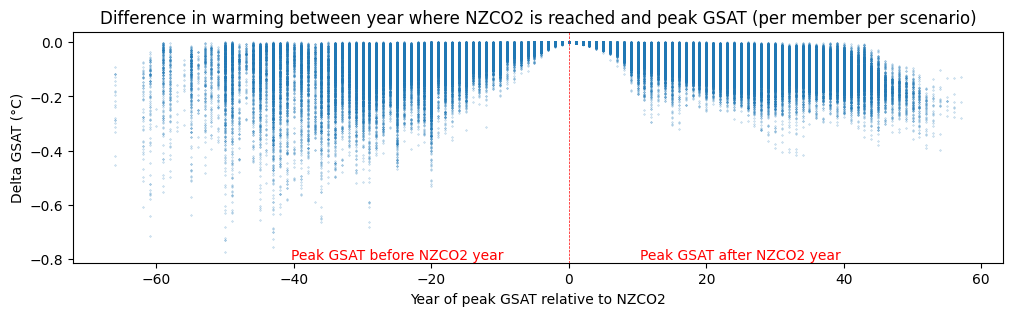

In [30]:
fig, ax = plt.subplots(figsize=(12, 3))

subset = all_df_extended[all_df_extended["scenario_group"]=="Scenarios (NZCO2)"]

x = subset["year_netzero_co2"] - subset["peak_year"]
y = subset["GSAT|ANTHROPOGENIC|netzero_co2"] - subset["GSAT|ANTHROPOGENIC|peak"]

ax.scatter(x, y, marker='x', s=0.8, alpha=.2)
ax.axvline(x=0, linestyle='--', c='red', linewidth=0.5)

# Position text near the top of the plot
y_text = -0.8

ax.text(
    -25,  # halfway between xmin and 0
    y_text,
    "Peak GSAT before NZCO2 year",
    ha="center",
    c="red"
)

ax.text(
    25,     # halfway between 0 and xmax
    y_text,
    "Peak GSAT after NZCO2 year",
    ha="center",
    c="red"
)

ax.set_title("Difference in warming between year where NZCO2 is reached and peak GSAT (per member per scenario)")
ax.set_xlabel("Year of peak GSAT relative to NZCO2")
ax.set_ylabel("Delta GSAT (°C)")

fig.savefig(PLOT_FOLDER / "501_peak_v_nzco2_timing.png", bbox_inches="tight", dpi=300)
    
plt.show()


# the delta is obviously negative or zero by definition, since otherwise the two years coincide

## Detailed Results by Group

In [31]:
# Base scenarios (no NZCO2 or NZKyoto)
print("Scenarios (NZCO2) (no net-zero suffix)")
print("=" * 50)
base_results = decline_prob[decline_prob["scenario_group"] == "Scenarios (NZCO2)"][
    ["model", "scenario", "n_ensemble", "n_decline", "prob_decline_pct"]
].sort_values("prob_decline_pct", ascending=False)
base_results

Scenarios (NZCO2) (no net-zero suffix)


,model,scenario,n_ensemble,n_decline,prob_decline_pct
392,MESSAGEix-GLOBIOM 1.1,ENGAGE-NPi2020-600f-DR10p,600,600,100.0
459,POLES ADVANCE,ADVANCE-2030-Price 1.5°C,600,600,100.0
510,REMIND 1.6,EMF30-Slower-to-Faster,600,600,100.0
484,POLES-JRC ENGAGE,ENGAGE-INDCi2030-400f,600,600,100.0
483,POLES-JRC ENGAGE,ENGAGE-INDCi2030-300f,600,600,100.0
...,...,...,...,...,...
475,POLES-JRC ENGAGE,ENGAGE-Feasibility-Maximum-Effort/Institutional,600,152,25.3
473,POLES-JRC ENGAGE,ENGAGE-Feasibility-1000/Technology & Enablers ...,600,151,25.2
219,IMAGE 3.2,ENGAGE-Feasibility-1000/Cost-Effective,600,148,24.7
150,GCAM 7.0,IAM-COMPACT-NDC-Long-Term-Pledges,600,145,24.2


In [32]:
# Base scenarios (no NZCO2 or NZKyoto)
print("Scenarios (NZGHG) (no net-zero suffix)")
print("=" * 50)
base_results = decline_prob[decline_prob["scenario_group"] == "Scenarios (NZGHG)"][
    ["model", "scenario", "n_ensemble", "n_decline", "prob_decline_pct"]
].sort_values("prob_decline_pct", ascending=False)
base_results

Scenarios (NZGHG) (no net-zero suffix)


,model,scenario,n_ensemble,n_decline,prob_decline_pct
1170,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,600,600,100.0
1076,REMIND-MAgPIE 1.5,SSP2-26,600,600,100.0
1088,REMIND-MAgPIE 1.7-3.0,EMF33-1.5°C-cost100,600,600,100.0
1087,REMIND-MAgPIE 1.7-3.0,COMMIT-Bridge,600,600,100.0
1086,REMIND-MAgPIE 1.7-3.0,COMMIT-2°C-2030,600,600,100.0
...,...,...,...,...,...
906,MESSAGE-GLOBIOM 1.0,SSP1-34,600,503,83.8
1147,WITCH 5.0,ENGAGE-INDCi2030-1200f,600,497,82.8
878,IMAGE 3.2,SSP2021-SSP2-SPA2-26-Default,600,481,80.2
845,GCAM 4.2,SSP4-34,600,460,76.7


In [33]:
# NZKyoto scenarios
print("Stylised Variants (NZGHG-hold)")
print("=" * 50)
nzkyoto_results = decline_prob[decline_prob["scenario_group"] == "Stylised Variants (NZGHG-hold)"][
    ["model", "scenario", "n_ensemble", "n_decline", "prob_decline_pct"]
].sort_values("prob_decline_pct", ascending=False)
nzkyoto_results

Stylised Variants (NZGHG-hold)


,model,scenario,n_ensemble,n_decline,prob_decline_pct
2277,REMIND-MAgPIE 2.1-4.2,CEMICS-SSP1-1.5°C-fullCDR_NZKyoto,600,600,100.0
2086,MESSAGEix-GLOBIOM 1.1,ENGAGE-Feasibility-1000/Enablers & Institution...,600,600,100.0
2234,REMIND 2.1,R2p1-SSP1-900_NZKyoto,600,600,100.0
2301,REMIND-MAgPIE 3.2.0-4.8.0,RESCUE-End-of-Century-Budget-500-with-OAE_NZKyoto,600,600,100.0
2236,REMIND 3.0,NAVIGATE Demand-1.5°C-act_u_NZKyoto,600,600,100.0
...,...,...,...,...,...
1991,COFFEE 1.1,ENGAGE-NPi2020-1000f-COV_NZKyoto,600,470,78.3
2049,IMAGE 3.2,SSP2021-SSP2-SPA2-26-Default_NZKyoto,600,461,76.8
2016,GCAM 4.2,SSP4-34_NZKyoto,600,460,76.7
2042,IMAGE 3.2,SSP2021-SSP1-SPA1-26-Default_NZKyoto,600,460,76.7


In [34]:
# NZCO2 scenarios
print("Stylised Variants (NZCO2-hold)")
print("=" * 50)
nzco2_results = decline_prob[decline_prob["scenario_group"] == "Stylised Variants (NZCO2-hold)"][
    ["model", "scenario", "n_ensemble", "n_decline", "prob_decline_pct"]
].sort_values("prob_decline_pct", ascending=False)
nzco2_results

Stylised Variants (NZCO2-hold)


,model,scenario,n_ensemble,n_decline,prob_decline_pct
1852,REMIND-MAgPIE 3.2-4.6,SHAPE-SDP-MC-1.5°C_NZCO2,600,600,100.0
1851,REMIND-MAgPIE 3.2-4.6,SHAPE-SDP-MC-1.5°C [with Climate Change Impact...,600,600,100.0
1864,REMIND-MAgPIE 3.3-4.8,NGFS Phase 5-Low Demand_NZCO2,600,599,99.8
1854,REMIND-MAgPIE 3.2-4.6,SHAPE-SDP-RC-1.5°C_NZCO2,600,599,99.8
1855,REMIND-MAgPIE 3.2-4.6,SHAPE-SSP1-1.5°C_NZCO2,600,599,99.8
...,...,...,...,...,...
1281,GCAM 5.2,NGFS Phase 1-Immediate 2C°C with CDR_NZCO2,600,78,13.0
1883,TIAM-ECN 1.1,ENGAGE-NPi2020-1200f_NZCO2,600,77,12.8
1277,GCAM 4.2,SSP4-34_NZCO2,600,66,11.0
1632,POLES EMF30,EMF30-D-CO2-Only_NZCO2,600,55,9.2
